In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dinoDatasetCSV.csv")

print(df)

     scientific_name     common_name          meaning       diet  length_m  \
0        Abelisaurus     Abelisaurus    Abel's lizard  Carnivore       7.0   
1      Abrictosaurus   Abrictosaurus   Wakeful lizard  Herbivore       1.5   
2         Abrosaurus      Abrosaurus  Delicate lizard  Herbivore       9.0   
3        Abydosaurus     Abydosaurus    Abydos lizard  Herbivore      18.0   
4       Acantholipan    Acantholipan     Spiny shield  Herbivore       5.0   
...              ...             ...              ...        ...       ...   
1537  Yunyangosaurus  Yunyangosaurus   Yunyang lizard  Carnivore       7.0   
1538      Yuxisaurus      Yuxisaurus      Yuxi lizard  Herbivore       4.5   
1539      Zaraapelta      Zaraapelta     Zaraa shield  Herbivore       5.0   
1540   Zhuchengtitan   Zhuchengtitan   Zhucheng titan  Herbivore      25.0   
1541      Zuoyunlong      Zuoyunlong    Zuoyun dragon  Herbivore      12.0   

      weight_kg  height_m   locomotion geological_period      l

## Cleaning Large Columns

In [3]:
df["geological_period"].unique()

<StringArray>
[                              'Late Cretaceous',
                                'Early Jurassic',
                               'Middle Jurassic',
                              'Early Cretaceous',
                                 'Late Jurassic',
                                'Late Triassic?',
               'Late Cretaceous (Maastrichtian)',
                                 'Late Triassic',
                   'Late Cretaceous (Campanian)',
                   'Early Jurassic (Sinemurian)',
                     'Early Cretaceous (Aptian)',
                  'Late Jurassic (Kimmeridgian)',
     'Early Jurassic (Sinemurian–Pliensbachian)',
     'Late Cretaceous (Campanian–Maastrichtian)',
                                    'Cretaceous',
                                      'Jurassic',
                  'Late Triassic–Early Jurassic',
                                      'Triassic',
                                'Mid Cretaceous',
                   'Late Cretaceous 

In [4]:
## there's way too many. Let's consolidate
def recode_period(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'cretaceous' in x:
        return 'Cretaceous'
    elif 'jurassic' in x:
        return 'Jurassic'
    elif 'triassic':
        return 'Triassic'
    else:
        'Other'

df['cleaned_geological_period'] = df['geological_period'].apply(recode_period)

In [5]:
df["cleaned_geological_period"].unique()

<StringArray>
['Cretaceous', 'Jurassic', 'Triassic']
Length: 3, dtype: str

In [6]:
df["locomotion"].unique()

<StringArray>
[                        'Bipedal',                     'Quadrupedal',
                        'Bipedal?',                         'Aquatic',
             'Bipedal/Quadrupedal', 'Bipedal (facultative quadruped)',
   'Bipedal/Facultative quadruped',                         'Unknown',
       'Bipedal/Early Quadrupedal',                          'Varies',
             'Quadrupedal/Bipedal',                     'Bipedal (?)',
            'Aquatic (Plesiosaur)',          'Bipedal/Early Sauropod',
                      'Locomotion',                               '?']
Length: 16, dtype: str

In [7]:
## there's too many. Let's consolidate
def recode_locomotion(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x or 'varies' in x:
        return 'Other'

    if 'aquatic' in x:
        return 'Aquatic'
    elif 'bipedal' in x and 'quadrupedal' in x:
        return 'Bipedal/Quadrupedal'    
    elif 'bipedal' in x:
        return 'Bipedal'
    else:
        return 'Quadrupedal'

df['cleaned_locomotion'] = df['locomotion'].apply(recode_locomotion)

In [8]:
df["cleaned_locomotion"].value_counts()

cleaned_locomotion
Bipedal                916
Quadrupedal            596
Other                   14
Bipedal/Quadrupedal     13
Aquatic                  3
Name: count, dtype: int64

In [9]:
df["diet"].unique()

<StringArray>
[           'Carnivore',            'Herbivore',             'Omnivore',
 'Carnivore (disputed)',        'Ceric unknown',          'Insectivore',
              'Unknown',   'Possibly carnivore',       'Tiny herbivore',
                 'Diet',                    '?']
Length: 11, dtype: str

In [10]:
## there's too many. Let's consolidate
def recode_diet(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'carnivore' in x:
        return 'Carnivore'
    elif 'herbivore' in x:
        return 'Herbivore'    
    elif 'omnivore' in x:
        return 'Omnivore'
    else:
        return 'Insectivore'

df['cleaned_diet'] = df['diet'].apply(recode_diet)

In [11]:
df["cleaned_diet"].value_counts()

cleaned_diet
Herbivore      972
Carnivore      505
Omnivore        53
Other           10
Insectivore      2
Name: count, dtype: int64

In [12]:
df["intelligence_level"].unique()

<StringArray>
[         'Medium',             'Low',      'Very Large',           'Large',
            'Tiny',         'Unknown',            'High', 'Possibly medium',
           'Small',            'Size',               '?',            'Huge',
      'Very small',      'Very large']
Length: 14, dtype: str

In [13]:
## there's too many. Let's consolidate
def recode_intelligence_level(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'small' in x or 'low' in x or 'tiny' in x:
        return 'Small'
    elif 'medium' in x:
        return 'Medium'    
    else:
        return 'Large'

df['cleaned_intelligence_level'] = df['intelligence_level'].apply(recode_intelligence_level)

In [14]:
df["cleaned_intelligence_level"].value_counts()

cleaned_intelligence_level
Medium    778
Small     385
Other     194
Large     185
Name: count, dtype: int64

In [15]:
df["first_discovered"].unique()

<StringArray>
['1985', '1974', '1959', '2010', '2011', '1865', '1993', '2007', '1877',
 '1991',
 ...
 '1940', '1907', '1928', '1944', '1808', '1909', '1978', 'Year',    '?',
 '2023']
Length: 171, dtype: str

In [16]:
def recode_first_discovered(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if '18' in x :
        return '1800-1899'
    elif '19' in x:
        return '1900-1999'    
    else:
        return '>2000'

df['cleaned_first_discovered'] = df['first_discovered'].apply(recode_first_discovered)

In [17]:
df["cleaned_first_discovered"].value_counts()

cleaned_first_discovered
>2000        705
1900-1999    646
1800-1899    186
Other          5
Name: count, dtype: int64

In [18]:
fossil_location_vc = df["fossil_location"].value_counts()

rare_locations = fossil_location_vc[fossil_location_vc < 5].index

In [19]:
def recode_fossil_location(x):
    if not isinstance(x, str):
        return 'Other'
    
    if x in rare_locations:
        return 'Other'
    else:
        return x

df['cleaned_fossil_location'] = df['fossil_location'].apply(recode_fossil_location)

In [20]:
df["cleaned_fossil_location"].value_counts()

cleaned_fossil_location
Other                                  437
China                                  238
USA                                    238
Argentina                              187
Canada                                  55
Mongolia                                46
UK                                      38
France                                  36
India                                   26
Brazil                                  23
Spain                                   19
England                                 17
Portugal                                16
South Africa                            12
Germany                                 12
Tanzania                                12
Thailand                                11
Mexico                                  10
Europe                                  10
Japan                                   10
Russia                                  10
Morocco                                  9
Elliot Formation, South Africa

In [21]:
df.duplicated().sum()

np.int64(0)

## Data Analysis

In [22]:
df.describe(include = 'str')

,scientific_name,common_name,meaning,diet,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
count,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542
unique,1538,1527,1338,11,16,73,133,599,171,351,744,14,1524,3,5,5,4,4,34
top,Kritosaurus,Kritosaurus,Different lizard,Herbivore,Bipedal,Late Cretaceous,North America,Theropod dinosaur,2019,China,Large sauropod,Medium,https://en.wikipedia.org/wiki/Kritosaurus,Cretaceous,Bipedal,Herbivore,Medium,>2000,Other
freq,3,3,20,971,913,659,253,265,100,238,86,777,3,1010,916,972,778,705,437


### histograms

array([[<Axes: title={'center': 'length_m'}>,
        <Axes: title={'center': 'weight_kg'}>],
       [<Axes: title={'center': 'height_m'}>,
        <Axes: title={'center': 'row_index'}>]], dtype=object)

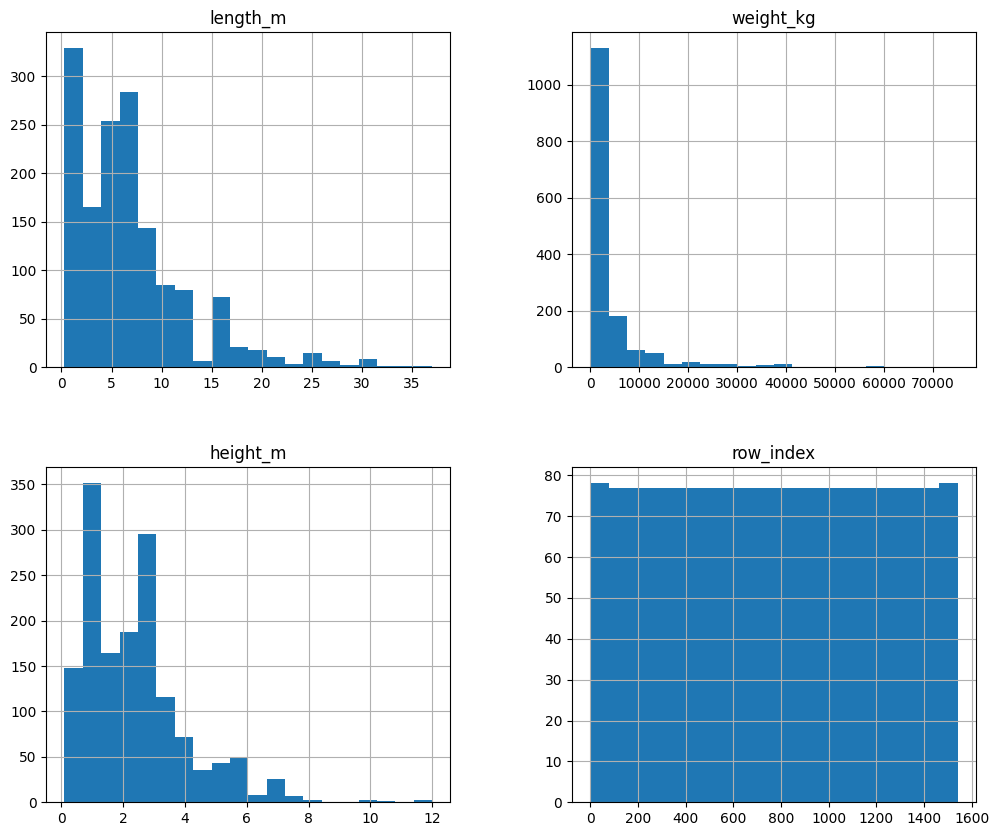

In [233]:
df.hist(figsize = (12,10), bins = 20)

### Scatterplots

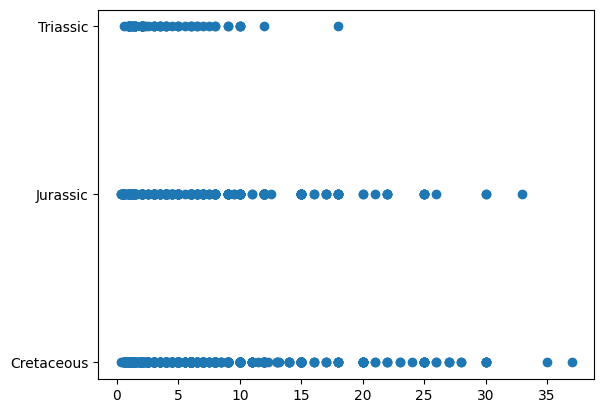

In [24]:
plt.scatter(df['length_m'], df['cleaned_geological_period'])

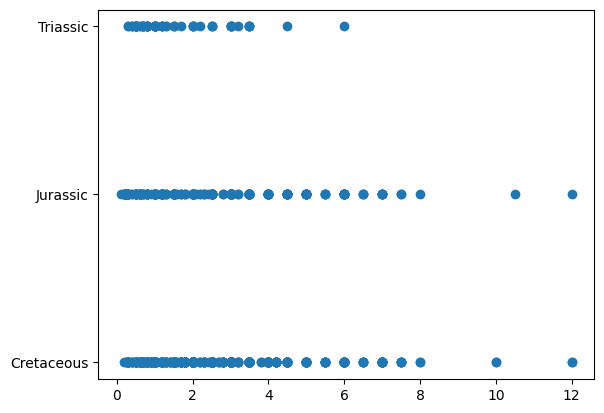

In [25]:
plt.scatter(df['height_m'], df['cleaned_geological_period'])

Text(0.5, 1.0, 'Weight vs Geological Period')

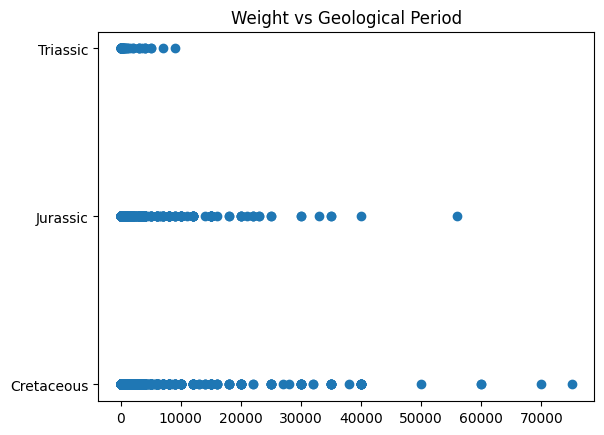

In [236]:
plt.scatter(df['weight_kg'], df['cleaned_geological_period'])
plt.title("Weight vs Geological Period")

Text(0.5, 1.0, 'Geological Period vs Locomotion')

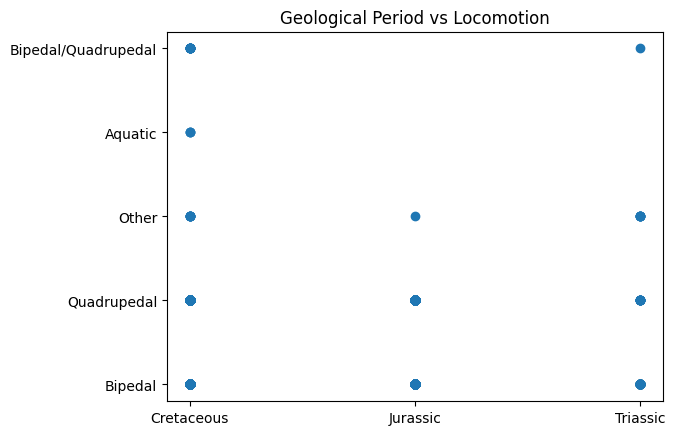

In [238]:
plt.scatter(df['cleaned_geological_period'],df['cleaned_locomotion'])
plt.title("Geological Period vs Locomotion")

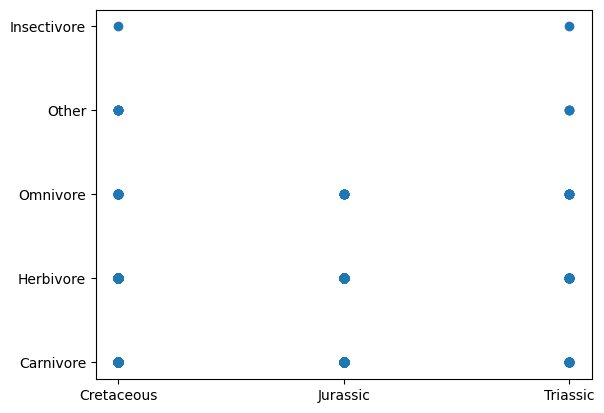

In [237]:
plt.scatter(df['cleaned_geological_period'], df['cleaned_diet'])

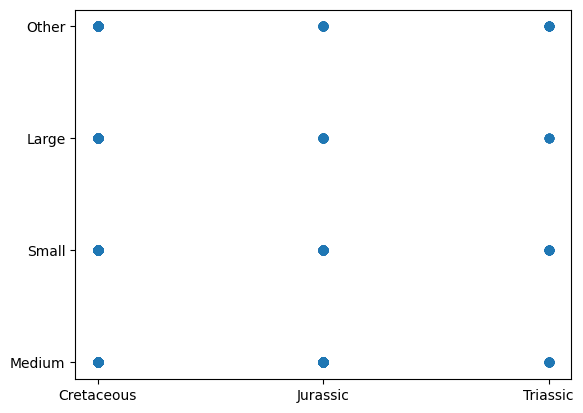

In [28]:
plt.scatter(df['cleaned_geological_period'], df['cleaned_intelligence_level'])

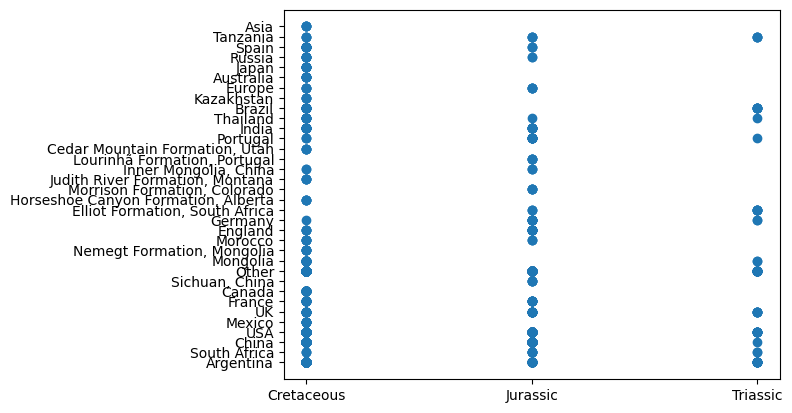

In [29]:
plt.scatter( df['cleaned_geological_period'], df['cleaned_fossil_location'])

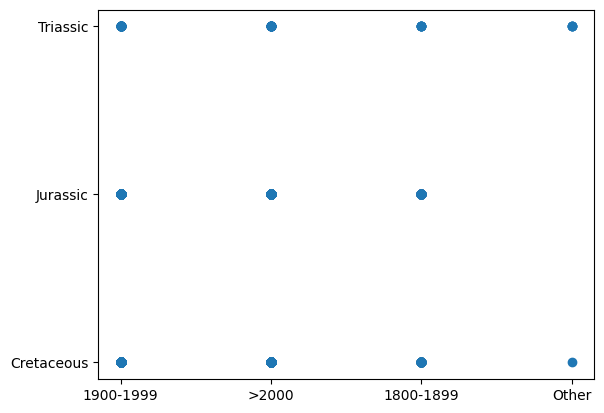

In [30]:
plt.scatter(df['cleaned_first_discovered'], df['cleaned_geological_period'])

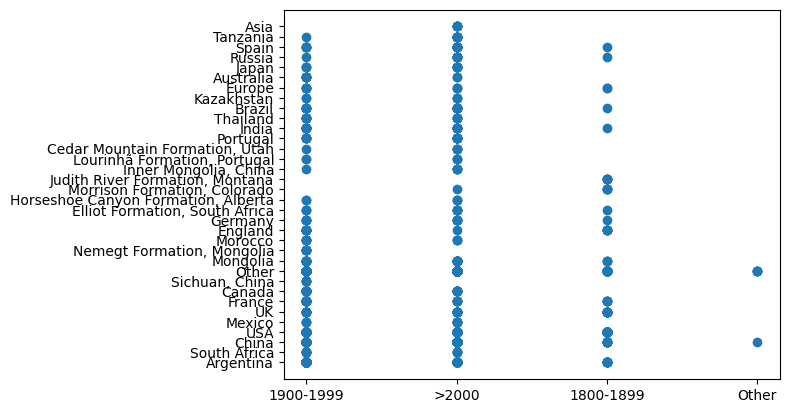

In [31]:
plt.scatter(df['cleaned_first_discovered'], df['cleaned_fossil_location'])

### outliers

<Axes: title={'center': 'Dinosaur Features Boxplots Before Handling Outliers'}>

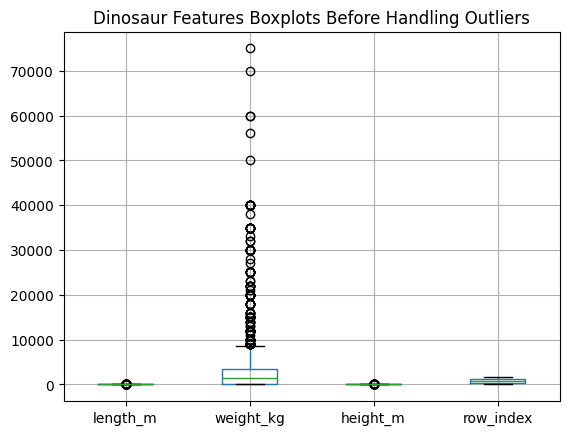

In [86]:
plt.title("Dinosaur Features Boxplots Before Handling Outliers")
df.select_dtypes(include=['number']).boxplot(figsize=(12,10))

In [80]:
## clipping outliers
def IQR(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw,uw

for x in ['length_m', 'weight_kg', 'height_m']:
    lw,uw = IQR(df[x])
    df[x] = np.clip(df[x], lw, uw)

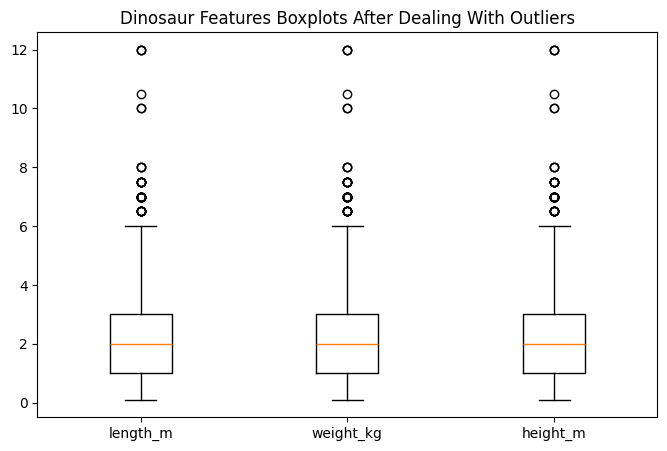

In [140]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df[x].dropna() for col in ['length_m','weight_kg','height_m']],
    tick_labels=['length_m','weight_kg','height_m']
)

plt.title("Dinosaur Features Boxplots After Dealing With Outliers")
plt.show()

## Check + Replace nan

In [33]:
df.isnull()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,...,notable_features,intelligence_level,source_link,row_index,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1540,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
np.any(df.isnull())

np.True_

In [35]:
## https://www.geeksforgeeks.org/python/check-for-nan-in-pandas-dataframe/

# applying the method
count_nan = df.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan))

Number of NaN values present: scientific_name                0
common_name                    0
meaning                        0
diet                           0
length_m                      39
weight_kg                     38
height_m                      32
locomotion                     0
geological_period              0
lived_in                       0
behavior_notes                 0
first_discovered               0
fossil_location                0
notable_features               0
intelligence_level             0
source_link                    0
row_index                      0
cleaned_geological_period      0
cleaned_locomotion             0
cleaned_diet                   0
cleaned_intelligence_level     0
cleaned_first_discovered       0
cleaned_fossil_location        0
dtype: int64


In [36]:
## Most of the dinosaurs that were missing height also missed weight and length. Dinosaurs with three unknowns were dropped

df_dropped_based_on_height = df.dropna(subset=['height_m'])

In [37]:
# applying the method
count_nan_2 = df_dropped_based_on_height.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_2))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      7
weight_kg                     6
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [38]:
# Replace "?" with blank entries
df_dropped_height_replaced_qs = df_dropped_based_on_height.replace("?", "")

# Preview result
print(df_dropped_height_replaced_qs.head())

  scientific_name    common_name          meaning       diet  length_m  \
0     Abelisaurus    Abelisaurus    Abel's lizard  Carnivore       7.0   
1   Abrictosaurus  Abrictosaurus   Wakeful lizard  Herbivore       1.5   
2      Abrosaurus     Abrosaurus  Delicate lizard  Herbivore       9.0   
3     Abydosaurus    Abydosaurus    Abydos lizard  Herbivore      18.0   
4    Acantholipan   Acantholipan     Spiny shield  Herbivore       5.0   

   weight_kg  height_m   locomotion geological_period      lived_in  ...  \
0     1500.0       2.4      Bipedal   Late Cretaceous     Argentina  ...   
1       15.0       0.5      Bipedal    Early Jurassic  South Africa  ...   
2     2000.0       4.5  Quadrupedal   Middle Jurassic         China  ...   
3    30000.0       6.0  Quadrupedal  Early Cretaceous           USA  ...   
4     2500.0       1.5  Quadrupedal   Late Cretaceous        Mexico  ...   

        notable_features intelligence_level  \
0             Short arms             Medium   
1   

In [39]:
# applying the method
count_nan_3 = df_dropped_height_replaced_qs.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_3))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      7
weight_kg                     6
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [40]:
df_new = df_dropped_height_replaced_qs.dropna(subset=['length_m'])

In [41]:
# applying the method
count_nan_4 = df_new.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_4))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      0
weight_kg                     1
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [42]:
row_finder = df_new[df_new["weight_kg"].isna()]
print(row_finder)

    scientific_name   common_name            meaning       diet  length_m  \
319    Achillobator  Abdarainurus  Abdrant Nuru tail  Herbivore      13.0   

     weight_kg  height_m   locomotion geological_period  lived_in  ...  \
319        NaN       4.0  Quadrupedal   Late Cretaceous  Mongolia  ...   

                                   notable_features intelligence_level  \
319  Very elongated neural spines on tail vertebrae                Low   

                                    source_link row_index  \
319  https://en.wikipedia.org/wiki/Abdarainurus       319   

    cleaned_geological_period cleaned_locomotion  cleaned_diet  \
319                Cretaceous        Quadrupedal     Herbivore   

    cleaned_intelligence_level cleaned_first_discovered  \
319                      Small                1900-1999   

    cleaned_fossil_location  
319                   Other  

[1 rows x 23 columns]


In [43]:
df_new.loc[df_new["weight_kg"].isna(), "weight_kg"] = 300.0

In [44]:
# applying the method
count_nan_5 = df_new.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_5))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      0
weight_kg                     0
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [45]:
## dropping dino name bc unnecessary in data

In [46]:
df.head()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,...,notable_features,intelligence_level,source_link,row_index,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,Abelisaurus,Abelisaurus,Abel's lizard,Carnivore,7.0,1500.0,2.4,Bipedal,Late Cretaceous,Argentina,...,Short arms,Medium,https://en.wikipedia.org/wiki/Abelisaurus,0,Cretaceous,Bipedal,Carnivore,Medium,1900-1999,Argentina
1,Abrictosaurus,Abrictosaurus,Wakeful lizard,Herbivore,1.5,15.0,0.5,Bipedal,Early Jurassic,South Africa,...,Unique teeth,Medium,https://en.wikipedia.org/wiki/Abrictosaurus,1,Jurassic,Bipedal,Herbivore,Medium,1900-1999,South Africa
2,Abrosaurus,Abrosaurus,Delicate lizard,Herbivore,9.0,2000.0,4.5,Quadrupedal,Middle Jurassic,China,...,Delicate skull,Medium,https://en.wikipedia.org/wiki/Abrosaurus,2,Jurassic,Quadrupedal,Herbivore,Medium,1900-1999,China
3,Abydosaurus,Abydosaurus,Abydos lizard,Herbivore,18.0,30000.0,6.0,Quadrupedal,Early Cretaceous,USA,...,Complete skull,Medium,https://en.wikipedia.org/wiki/Abydosaurus,3,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,USA
4,Acantholipan,Acantholipan,Spiny shield,Herbivore,5.0,2500.0,1.5,Quadrupedal,Late Cretaceous,Mexico,...,Clubless armored tail,Medium,https://en.wikipedia.org/wiki/Acantholipan,4,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mexico


In [47]:
df_new = df_new.drop(columns=["notable_features", "scientific_name", "common_name", "meaning", "behavior_notes", "row_index", "source_link",
                             "intelligence_level", "lived_in", "geological_period", "locomotion", "diet", "first_discovered",
                             "fossil_location"])

In [48]:
df_new.head()

,length_m,weight_kg,height_m,notable_features,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,7.0,1500.0,2.4,Short arms,Cretaceous,Bipedal,Carnivore,Medium,1900-1999,Argentina
1,1.5,15.0,0.5,Unique teeth,Jurassic,Bipedal,Herbivore,Medium,1900-1999,South Africa
2,9.0,2000.0,4.5,Delicate skull,Jurassic,Quadrupedal,Herbivore,Medium,1900-1999,China
3,18.0,30000.0,6.0,Complete skull,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,USA
4,5.0,2500.0,1.5,Clubless armored tail,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mexico


In [50]:
df_new

,length_m,weight_kg,height_m,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,7.0,1500.0,2.4,Cretaceous,Bipedal,Carnivore,Medium,1900-1999,Argentina
1,1.5,15.0,0.5,Jurassic,Bipedal,Herbivore,Medium,1900-1999,South Africa
2,9.0,2000.0,4.5,Jurassic,Quadrupedal,Herbivore,Medium,1900-1999,China
3,18.0,30000.0,6.0,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,USA
4,5.0,2500.0,1.5,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mexico
...,...,...,...,...,...,...,...,...,...
1537,7.0,700.0,2.5,Cretaceous,Bipedal,Carnivore,Medium,>2000,China
1538,4.5,1500.0,2.0,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,China
1539,5.0,2000.0,1.5,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mongolia
1540,25.0,30000.0,6.0,Cretaceous,Quadrupedal,Herbivore,Large,>2000,China


# Data Preprocessing

## Label Encoding

In [51]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 1503 entries, 0 to 1541
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   length_m                    1503 non-null   float64
 1   weight_kg                   1503 non-null   float64
 2   height_m                    1503 non-null   float64
 3   cleaned_geological_period   1503 non-null   str    
 4   cleaned_locomotion          1503 non-null   str    
 5   cleaned_diet                1503 non-null   str    
 6   cleaned_intelligence_level  1503 non-null   str    
 7   cleaned_first_discovered    1503 non-null   str    
 8   cleaned_fossil_location     1503 non-null   str    
dtypes: float64(3), str(6)
memory usage: 117.4 KB


In [52]:
df_new

,length_m,weight_kg,height_m,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,7.0,1500.0,2.4,Cretaceous,Bipedal,Carnivore,Medium,1900-1999,Argentina
1,1.5,15.0,0.5,Jurassic,Bipedal,Herbivore,Medium,1900-1999,South Africa
2,9.0,2000.0,4.5,Jurassic,Quadrupedal,Herbivore,Medium,1900-1999,China
3,18.0,30000.0,6.0,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,USA
4,5.0,2500.0,1.5,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mexico
...,...,...,...,...,...,...,...,...,...
1537,7.0,700.0,2.5,Cretaceous,Bipedal,Carnivore,Medium,>2000,China
1538,4.5,1500.0,2.0,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,China
1539,5.0,2000.0,1.5,Cretaceous,Quadrupedal,Herbivore,Medium,>2000,Mongolia
1540,25.0,30000.0,6.0,Cretaceous,Quadrupedal,Herbivore,Large,>2000,China


In [53]:
df_new = pd.get_dummies(df_new, columns=["cleaned_locomotion", "cleaned_diet", "cleaned_intelligence_level",
                                        "cleaned_first_discovered", "cleaned_fossil_location"])

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new["cleaned_geological_period"] = le.fit_transform(df_new["cleaned_geological_period"])

In [55]:
df_new

,length_m,weight_kg,height_m,cleaned_geological_period,cleaned_locomotion_Aquatic,cleaned_locomotion_Bipedal,cleaned_locomotion_Bipedal/Quadrupedal,cleaned_locomotion_Other,cleaned_locomotion_Quadrupedal,cleaned_diet_Carnivore,...,cleaned_fossil_location_Other,cleaned_fossil_location_Portugal,cleaned_fossil_location_Russia,"cleaned_fossil_location_Sichuan, China",cleaned_fossil_location_South Africa,cleaned_fossil_location_Spain,cleaned_fossil_location_Tanzania,cleaned_fossil_location_Thailand,cleaned_fossil_location_UK,cleaned_fossil_location_USA
0,7.0,1500.0,2.4,0,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,1.5,15.0,0.5,1,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,9.0,2000.0,4.5,1,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,18.0,30000.0,6.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,5.0,2500.0,1.5,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,7.0,700.0,2.5,0,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1538,4.5,1500.0,2.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1539,5.0,2000.0,1.5,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1540,25.0,30000.0,6.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Train/Test

In [90]:
from sklearn.model_selection import train_test_split

In [96]:
X = df_new.drop('cleaned_geological_period', axis = 1)
y = df_new['cleaned_geological_period']

print('Target variable distribution:')
print(y.value_counts().sort_index())
print(f'\nClass mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic\n')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42, stratify = y)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Target variable distribution:
cleaned_geological_period
0    988
1    439
2     76
Name: count, dtype: int64

Class mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic

Training set size: 1202 samples
Test set size: 301 samples
Number of features: 55


## Scaling

In [105]:
from sklearn.preprocessing import StandardScaler

## using this for logistic regression and KNN

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [159]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [171]:
model_logreg = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

In [172]:
model_logreg = LogisticRegression(max_iter=5000, class_weight = 'balanced')
model_logreg.fit(X_train_scaled, y_train)

y_pred_logreg = model_logreg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred))

Accuracy: 0.6179401993355482
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       198
           1       0.56      0.66      0.61        88
           2       0.15      0.53      0.24        15

    accuracy                           0.62       301
   macro avg       0.51      0.60      0.51       301
weighted avg       0.71      0.62      0.65       301



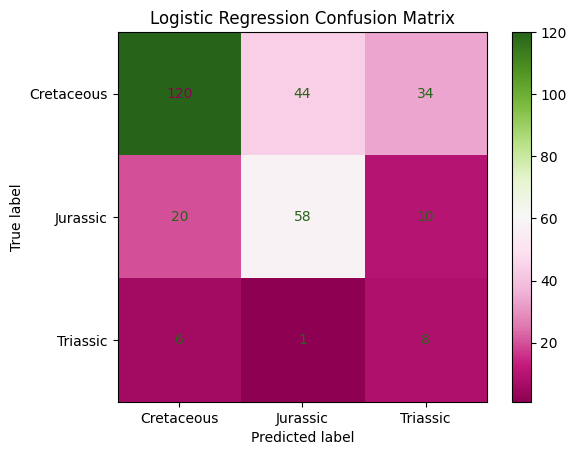

In [173]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display_log_reg = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), 
                                            display_labels=["Cretaceous", "Jurassic", "Triassic"])

cm_display_log_reg.plot(cmap='PiYG')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

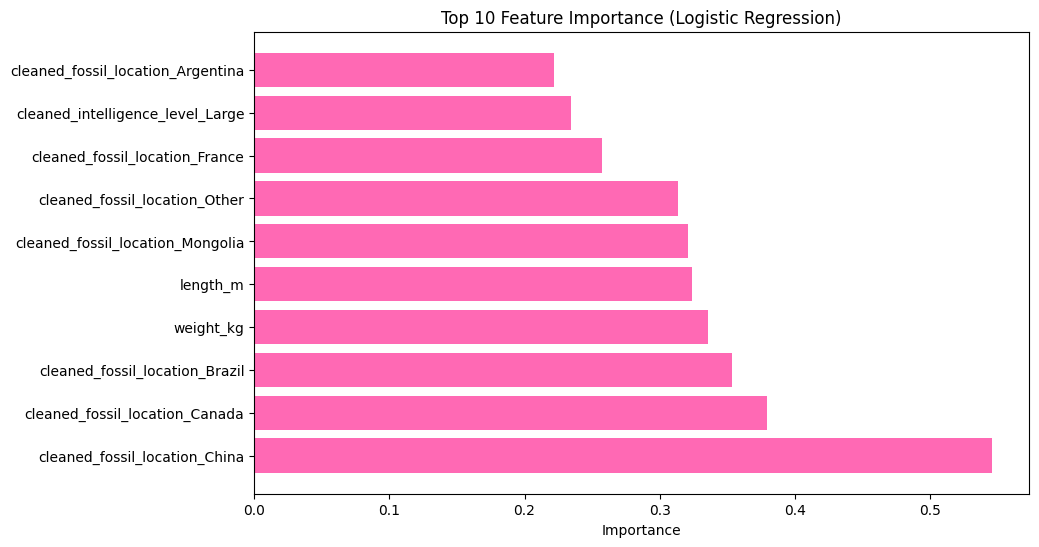

In [177]:
coefs_logreg = model_logreg.coef_

importance_logreg = np.mean(np.abs(coefs_logreg), axis=0)
feature_importance_logreg = pd.Series(importance_logreg, index=X.columns)

feature_importance_logreg = feature_importance_logreg.sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feature_importance_logreg.index[:10], feature_importance_logreg.values[:10],color = 'hotpink')
plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Importance")
plt.show()

## Random Forest

In [181]:
from sklearn.ensemble import RandomForestClassifier

In [244]:
model_rf = RandomForestClassifier(n_estimators=200, class_weight = 'balanced', random_state = 42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.72      0.91      0.81       198
           1       0.69      0.39      0.50        88
           2       0.00      0.00      0.00        15

    accuracy                           0.71       301
   macro avg       0.47      0.43      0.43       301
weighted avg       0.68      0.71      0.68       301



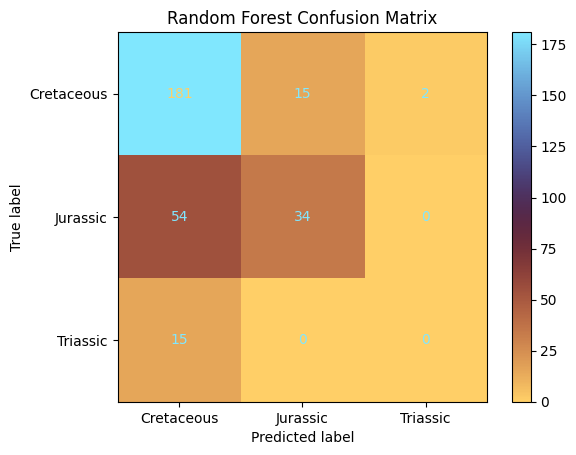

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), 
                                            display_labels=["Cretaceous", "Jurassic", "Triassic"])

cm_display_rf.plot(cmap='managua')
plt.title('Random Forest Confusion Matrix')
plt.show()

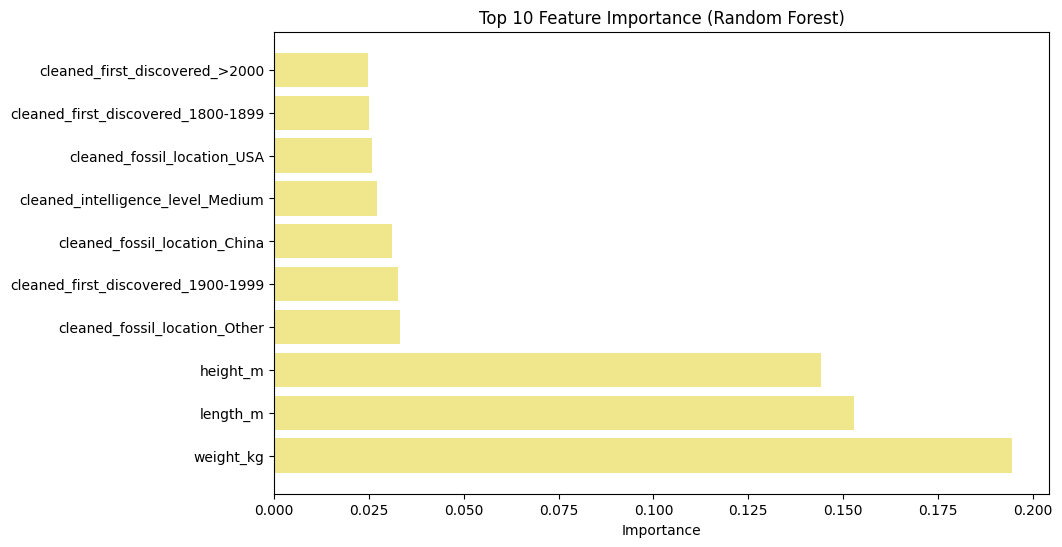

In [195]:
coefs_rf = model_rf.feature_importances_

importance_rf = np.mean(np.abs(coefs_rf), axis=0)
feature_importance_rf = pd.Series(model_rf.feature_importances_, index=X.columns)
feature_importance_rf = feature_importance_rf.sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feature_importance_rf.index[:10], feature_importance_rf.values[:10],color = 'khaki')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## KNN

In [197]:
from sklearn.neighbors import KNeighborsClassifier

In [219]:
from sklearn.pipeline import make_pipeline

model_knn = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    KNeighborsClassifier(n_neighbors = 5)
)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

In [223]:
model_knn = KNeighborsClassifier(n_neighbors = 5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7043189368770764
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       198
           1       0.58      0.40      0.47        88
           2       1.00      0.13      0.24        15

    accuracy                           0.70       301
   macro avg       0.77      0.47      0.50       301
weighted avg       0.70      0.70      0.68       301



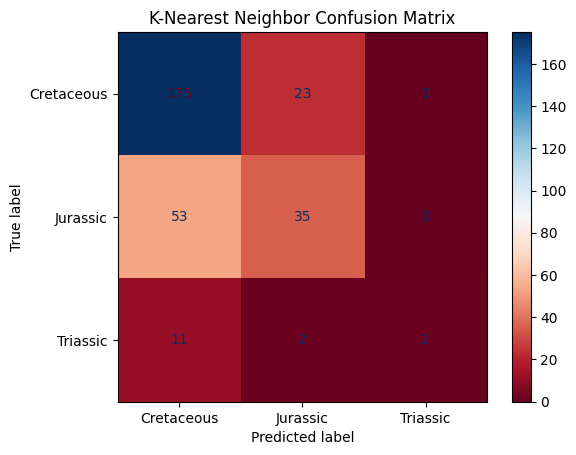

In [224]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display_knn = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), 
                                            display_labels=["Cretaceous", "Jurassic", "Triassic"])

cm_display_knn.plot(cmap='RdBu')
plt.title('K-Nearest Neighbor Confusion Matrix')
plt.show()

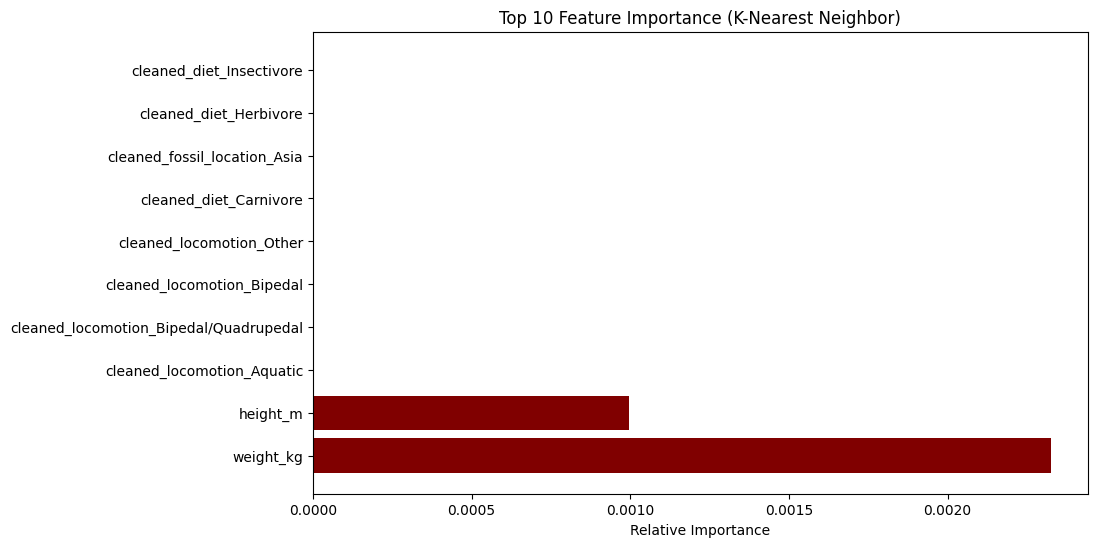

In [231]:
from sklearn.inspection import permutation_importance
result_knn = permutation_importance(
    model_knn, X_test.values, y_test,
    n_repeats=10,
    random_state=42
)

importance_knn = result_knn.importances_mean
feature_importance_knn = pd.Series(importance_knn, index=X.columns)
feature_importance_knn = feature_importance_knn.sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feature_importance_knn.index[:10], feature_importance_knn.values[:10],color = 'maroon')
plt.title("Top 10 Feature Importance (K-Nearest Neighbor)")
plt.xlabel("Relative Importance")
plt.show()

In [229]:
## shuffling weight and height causes largest decrease in accuracy
print(feature_importance_knn.head(10))

weight_kg                                 0.002326
height_m                                  0.000997
cleaned_locomotion_Aquatic                0.000000
cleaned_locomotion_Bipedal/Quadrupedal    0.000000
cleaned_locomotion_Bipedal                0.000000
cleaned_locomotion_Other                  0.000000
cleaned_diet_Carnivore                    0.000000
cleaned_fossil_location_Asia              0.000000
cleaned_diet_Herbivore                    0.000000
cleaned_diet_Insectivore                  0.000000
dtype: float64


## Comparing Models

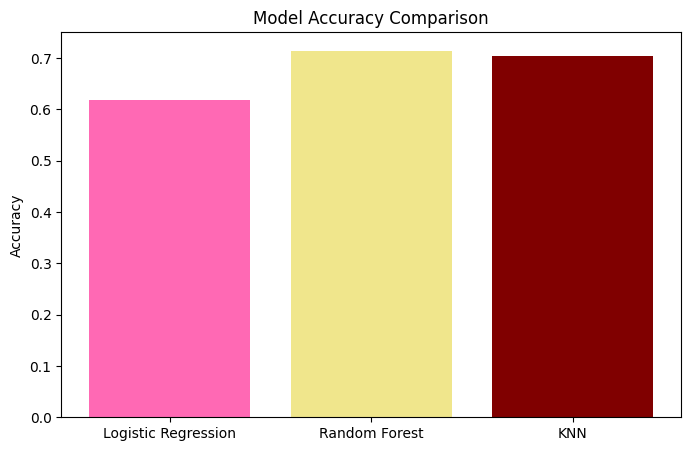

In [243]:
models = ['Logistic Regression', 'Random Forest', 'KNN']
accuracy = [0.6179, 0.7143, 0.7043]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color=['hotpink', 'khaki', 'maroon'])

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

In [242]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [0.6179, 0.7143, 0.7043],
    "Precision": [0.71, 0.68, 0.70],
    "Recall": [0.62, 0.71, 0.70],
    "F1-score": [0.65, 0.68, 0.68]})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6179,0.71,0.62,0.65
1,Random Forest,0.7143,0.68,0.71,0.68
2,KNN,0.7043,0.70,0.70,0.68
